# Использование `K-means` для сжатия


Еще одно полезное применение кластеризации — сжатие изображений. Схема до удивления проста: похожие, рядом расположенные цвета, стоит объединить в один цвет. Давайте провернем это самостоятельно.

Считайте изображение из вашего индивидуального задания.

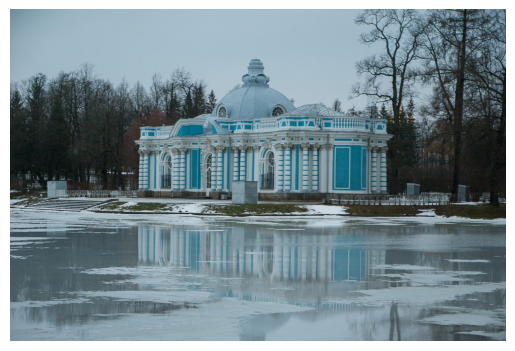

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from sklearn.cluster import MiniBatchKMeans


# Путь к изображению
img_path = './data/spb_barocco.jpg'

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.imshow(img)

Перед нами трехканальное (RGB) изображение. Вычислите среднее значение интенсивности пикселей по всем каналам.

In [2]:
f"{img.mean():.3f}"

'121.342'

Нормируйте значения интенсивностей пикселей, разделив все значения на $255$. Вычислите среднее значение интенсивности пикселей по всем каналам после проделанного преобразования.

In [3]:
img_norm = img / 255
f"{img_norm.mean():.3f}"

'0.476'

Давайте убедимся в том, что исходное пространство цветов, насчитывающее около $16$ миллионов возможных состояний ($256^3$), слишком велико, и его размерность можно понижать. Для наглядности построим лишь некоторые подвыборки зависимостей значений интенсивностей и лишь на случайном поднаборе пикселей.

«Распрямите» изображение так, чтобы <code>.shape</code> соответствущего массива имел вид <code>(высота * ширина, 3)</code>

In [4]:
# Функция принимает на вход "распрямленный" массив, соответствующий изображению

def plot_pixels(data, colors=None, N=10000):
    if colors is None:
        colors = data

    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

In [5]:
img_shape = img_norm.shape

In [6]:
img_norm = img_norm.reshape((img_shape[0] * img_shape[1], 3))
img_norm.shape

(1095680, 3)

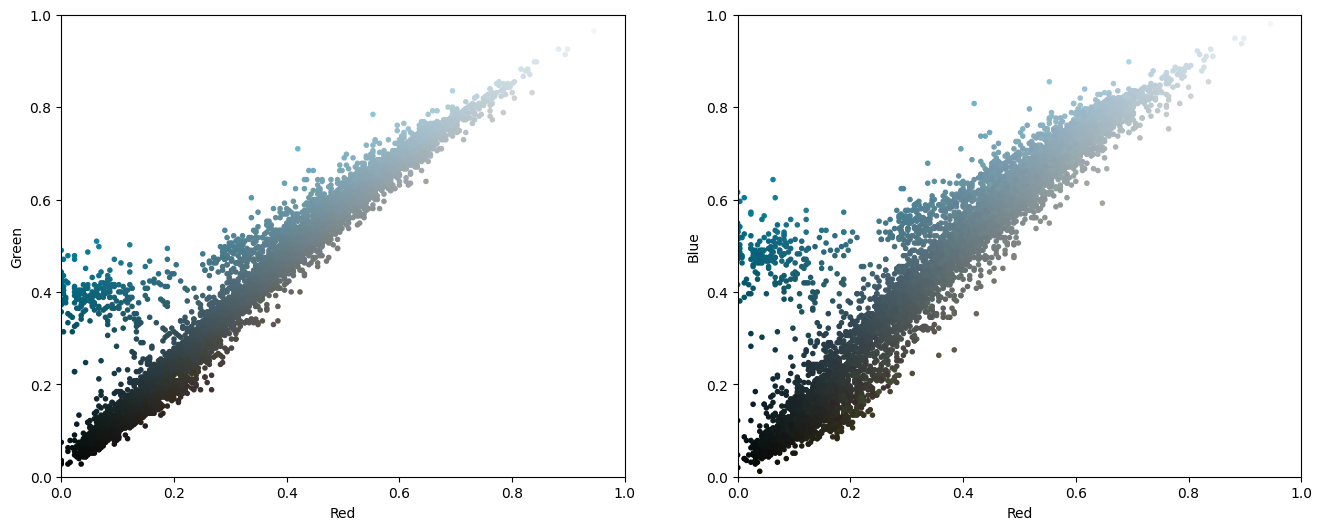

In [7]:
plot_pixels(img_norm)

Переведем 16 миллионов возможностей во всего-навсего 16 возможностей, используя <code>K-means</code>. Правда, чтобы ускорить работу алгоритма, мы будем использовать <a href="https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html"><code>K-means</code> на батчах</a> — поднаборах данных. Заодно увидим, портит ли это результат.

Обучите модель <code>MiniBatchKMeans</code> на нормированном и «распрямленном» изображении с параметрами, указанными в вашем задании.

В изображении замените значения цветов каждого пикселя на значения координат центроида кластера к которому был отнесен этот пиксель. Постройте графики зависимостей цветов при помощи <code>plot_pixels()</code> с новой палитрой (параметр <code>colors</code>)


In [8]:
kmeans = MiniBatchKMeans(n_clusters = 16, random_state = 16).fit(img_norm)
kmeans.cluster_centers_

array([[0.11686502, 0.13583509, 0.12614316],
       [0.50906701, 0.60212927, 0.64399267],
       [0.33615179, 0.40277985, 0.42708695],
       [0.64922906, 0.73904486, 0.78834819],
       [0.17868242, 0.20271393, 0.19528633],
       [0.23757301, 0.28856904, 0.30214852],
       [0.42335351, 0.49832894, 0.52543846],
       [0.59641389, 0.68588265, 0.72934942],
       [0.34739457, 0.51004566, 0.57245501],
       [0.0762465 , 0.38941176, 0.47219888],
       [0.28682823, 0.35197406, 0.37498767],
       [0.75495224, 0.81797386, 0.84781297],
       [0.46759214, 0.5557104 , 0.59244495],
       [0.36133736, 0.45047763, 0.48462167],
       [0.06352941, 0.08278401, 0.07708427],
       [0.55389672, 0.64241104, 0.68320911]])

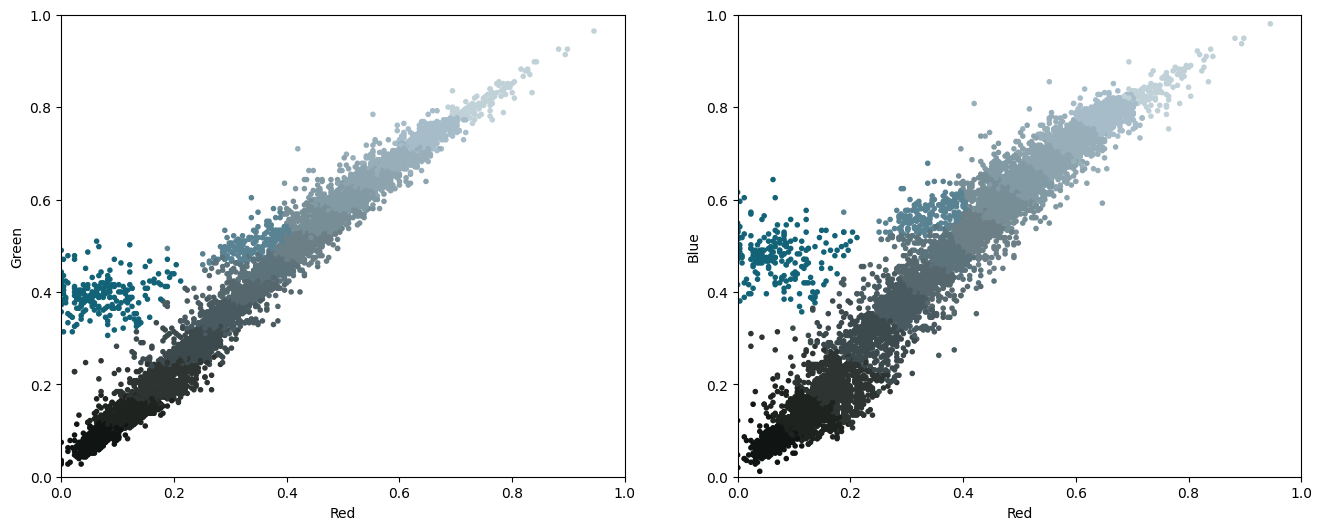

In [9]:
new_colors = np.array([kmeans.cluster_centers_[kmeans.labels_[i]] for i in range(len(kmeans.labels_))])
plot_pixels(img_norm, colors = new_colors)

Вычислите среднее значение интенсивности пикселей полученного изображения.

In [10]:
f"{new_colors.mean():.3f}"

'0.476'

Выберите номер изображения, соответствующего палитре из $16$ цветов.

In [11]:
# 2

Пора смотреть на результат! Постройте рядом оригинальное изображение и изображение, в котором используется лишь $16$ цветов.

In [12]:
colors = kmeans.cluster_centers_ * 255
colors = colors.astype(np.uint8)

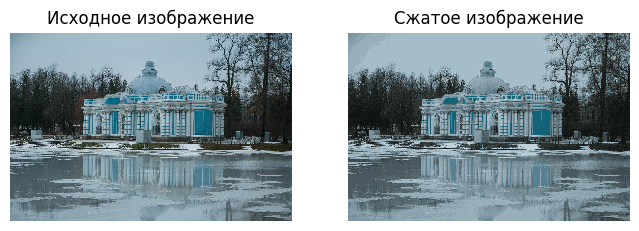

In [13]:
image1 = img
image2 = new_colors.reshape(img_shape[0], img_shape[1], 3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.imshow(image1, interpolation='nearest')
ax1.axis('off')
ax1.set_title("Исходное изображение")

# Второй график (справа)
ax2.imshow(image2, interpolation='nearest')
ax2.axis('off')
ax2.set_title("Сжатое изображение")

# Отображаем
plt.show()

Постройте изображение размера $4 \times 4$ на основе полученных $16$ цветов. Выберите верное изображение.

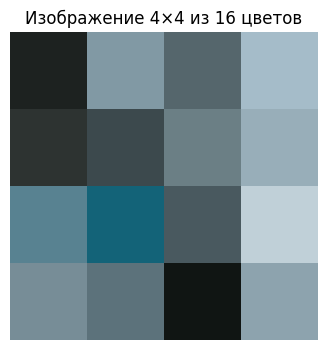

In [14]:
image = colors.reshape(4, 4, 3)

# Визуализируем
plt.figure(figsize=(4, 4))
plt.imshow(image, interpolation='nearest')
plt.axis('off')  # Убираем оси
plt.title("Изображение 4×4 из 16 цветов")
plt.show()